# Problem 1

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

In [40]:
column_names = [f'feature_{i}' for i in range(57)] + ['target']
data = pd.read_csv('spambase.data', header=None, names=column_names)

# Split features and labels
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [41]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train on training data
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [42]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

y_train_prob = dt.predict_proba(X_train)[:, 1]
y_test_prob = dt.predict_proba(X_test)[:, 1]

In [43]:
train_error = 1 - accuracy_score(y_train, y_train_pred)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

test_error = 1 - accuracy_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Training Metrics:")
print(f"Error: {train_error:.3f}, Accuracy: {train_accuracy:.3f}, F1: {train_f1:.3f}, AUC: {train_auc:.3f}")

print("\nTesting Metrics:")
print(f"Error: {test_error:.3f}, Accuracy: {test_accuracy:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

Training Metrics:
Error: 0.000, Accuracy: 1.000, F1: 1.000, AUC: 1.000

Testing Metrics:
Error: 0.081, Accuracy: 0.919, F1: 0.903, AUC: 0.917


In [44]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)

dt_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [45]:
y_train_pred_gini = dt_gini.predict(X_train)
y_test_pred_gini = dt_gini.predict(X_test)

y_train_prob_gini = dt_gini.predict_proba(X_train)[:, 1]
y_test_prob_gini = dt_gini.predict_proba(X_test)[:, 1]

In [46]:
train_error_gini = 1 - accuracy_score(y_train, y_train_pred_gini)
train_accuracy_gini = accuracy_score(y_train, y_train_pred_gini)
train_f1_gini = f1_score(y_train, y_train_pred_gini)
train_auc_gini = roc_auc_score(y_train, y_train_prob_gini)

test_error_gini = 1 - accuracy_score(y_test, y_test_pred_gini)
test_accuracy_gini = accuracy_score(y_test, y_test_pred_gini)
test_f1_gini = f1_score(y_test, y_test_pred_gini)
test_auc_gini = roc_auc_score(y_test, y_test_prob_gini)

print("Training Metrics (Gini):")
print(f"Error: {train_error_gini:.3f}, Accuracy: {train_accuracy_gini:.3f}, F1: {train_f1_gini:.3f}, AUC: {train_auc_gini:.3f}")

print("\nTesting Metrics (Gini):")
print(f"Error: {test_error_gini:.3f}, Accuracy: {test_accuracy_gini:.3f}, F1: {test_f1_gini:.3f}, AUC: {test_auc_gini:.3f}")

Training Metrics (Gini):
Error: 0.000, Accuracy: 1.000, F1: 1.000, AUC: 1.000

Testing Metrics (Gini):
Error: 0.101, Accuracy: 0.899, F1: 0.879, AUC: 0.898


In [47]:
max_depths = range(1, 21)
train_errors = []
test_errors = []

for depth in max_depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    
    train_errors.append(1 - accuracy_score(y_train, y_train_pred))
    test_errors.append(1 - accuracy_score(y_test, y_test_pred))

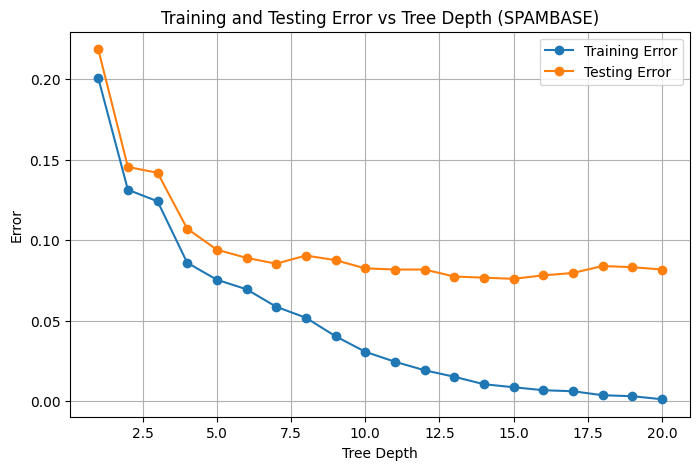

In [48]:
plt.figure(figsize=(8,5))
plt.plot(max_depths, train_errors, marker='o', label='Training Error')
plt.plot(max_depths, test_errors, marker='o', label='Testing Error')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Training and Testing Error vs Tree Depth (SPAMBASE)')
plt.legend()
plt.grid(True)
plt.show()

# Problem 2

In [49]:
tree_counts = [10, 50, 100, 500]

results = []

for T in tree_counts:
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    y_train_prob = rf.predict_proba(X_train)[:,1]
    y_test_prob = rf.predict_proba(X_test)[:,1]
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    results.append({
        'T': T,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Train F1': train_f1,
        'Test F1': test_f1,
        'Train AUC': train_auc,
        'Test AUC': test_auc
    })

results_df = pd.DataFrame(results)
print(results_df)

     T  Train Accuracy  Test Accuracy  Train F1   Test F1  Train AUC  Test AUC
0   10        0.995342       0.943519  0.993900  0.930481   0.999968  0.979618
1   50        0.999689       0.956553  0.999596  0.946996   0.999999  0.988360
2  100        0.999689       0.956553  0.999596  0.946903   0.999999  0.987965
3  500        0.999689       0.955105  0.999596  0.945326   1.000000  0.987939


In [ ]:
rf_final = RandomForestClassifier(n_estimators=500, random_state=42)
rf_final.fit(X_train, y_train)

importances = rf_final.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp_df)

       Feature  Importance
51  feature_51    0.115017
52  feature_52    0.098381
6    feature_6    0.084737
54  feature_54    0.065955
15  feature_15    0.065598
20  feature_20    0.055968
55  feature_55    0.053524
56  feature_56    0.044291
24  feature_24    0.041116
23  feature_23    0.035309
4    feature_4    0.033113
18  feature_18    0.030454
22  feature_22    0.023739
26  feature_26    0.022289
25  feature_25    0.016231
45  feature_45    0.015155
7    feature_7    0.014535
36  feature_36    0.013143
49  feature_49    0.012438
16  feature_16    0.012130
11  feature_11    0.011943
44  feature_44    0.010364
2    feature_2    0.009900
5    feature_5    0.008734
10  feature_10    0.008076
9    feature_9    0.007844
17  feature_17    0.007642
19  feature_19    0.006235
1    feature_1    0.006004
27  feature_27    0.005354
48  feature_48    0.004676
0    feature_0    0.004480
8    feature_8    0.004405
41  feature_41    0.004390
35  feature_35    0.004057
53  feature_53    0.003791
2

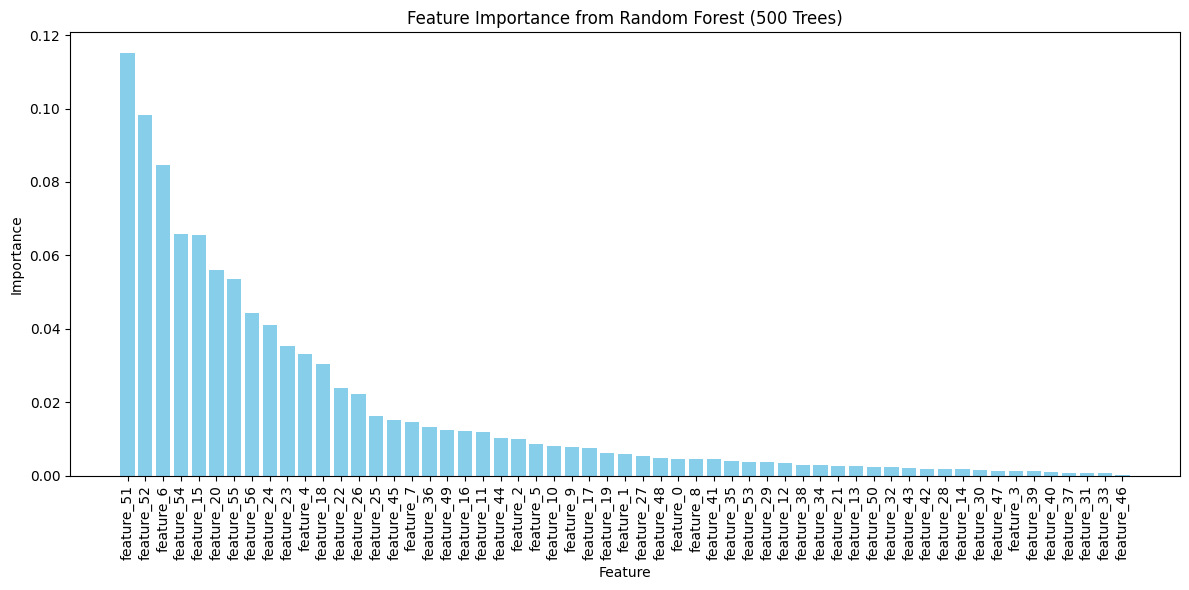

In [51]:
plt.figure(figsize=(12,6))
plt.bar(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.xticks(rotation=90)
plt.title('Feature Importance from Random Forest (500 Trees)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# Problem 3

In [56]:
from sklearn.metrics import roc_curve, auc

tree_counts = [10, 50, 100, 500]

ada_results = []
for T in tree_counts:
    ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=T, random_state=42)
    ada.fit(X_train, y_train)

    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)

    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]

    ada_results.append({
        'T': T,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Train AUC': roc_auc_score(y_train, y_train_prob),
        'Test AUC': roc_auc_score(y_test, y_test_prob)
    })

ada_results_df = pd.DataFrame(ada_results)
print("AdaBoost results:")
print(ada_results_df)

rf_df = results_df.copy()
rf_df = rf_df.set_index('T').add_prefix('RF ')
ada_df = ada_results_df.set_index('T').add_prefix('Ada ')
comparison_df = pd.concat([rf_df, ada_df], axis=1)
print("\nComparison (RF vs AdaBoost):")
print(comparison_df)

rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)
ada_100 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42)
ada_100.fit(X_train, y_train)

try:
    _ = y_test_prob
except NameError:
    y_test_prob = dt.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_100.predict_proba(X_test)[:, 1])
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_100.predict_proba(X_test)[:, 1])

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ada = auc(fpr_ada, tpr_ada)


AdaBoost results:
     T  Train Accuracy  Test Accuracy  Train F1   Test F1  Train AUC  Test AUC
0   10        0.913043       0.905865  0.885714  0.885764   0.962619  0.963525
1   50        0.929193       0.933382  0.906173  0.917563   0.978611  0.979255
2  100        0.938509       0.938450  0.918451  0.924039   0.982236  0.982648
3  500        0.950621       0.948588  0.934916  0.937445   0.989618  0.985455

Comparison (RF vs AdaBoost):
     RF Train Accuracy  RF Test Accuracy  RF Train F1  RF Test F1  \
T                                                                   
10            0.995342          0.943519     0.993900    0.930481   
50            0.999689          0.956553     0.999596    0.946996   
100           0.999689          0.956553     0.999596    0.946903   
500           0.999689          0.955105     0.999596    0.945326   

     RF Train AUC  RF Test AUC  Ada Train Accuracy  Ada Test Accuracy  \
T                                                                    

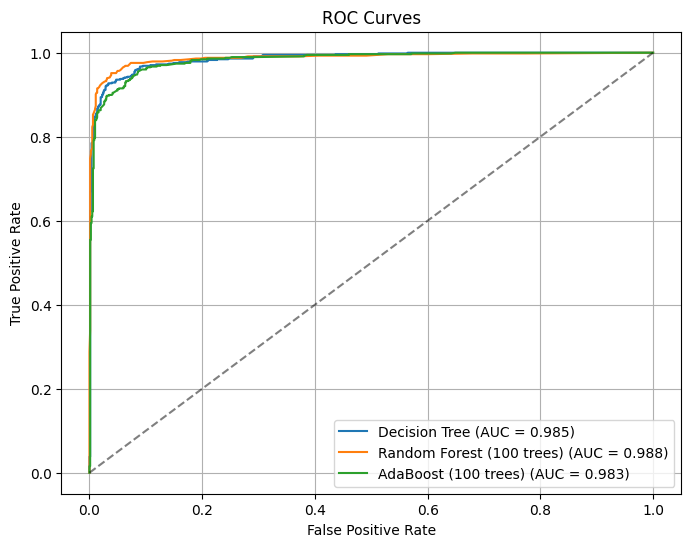

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (100 trees) (AUC = {auc_rf:.3f})')
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (100 trees) (AUC = {auc_ada:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.show()

# Problem 4

In [64]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import MultinomialNB

col_names = [
    'class','cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color',
    'stalk-shape','stalk-root','stalk-surface-above-ring','stalk-surface-below-ring',
    'stalk-color-above-ring','stalk-color-below-ring','veil-type','veil-color',
    'ring-number','ring-type','spore-print-color','population','habitat'
]

data = pd.read_csv('agaricus-lepiota.data', header=None, names=col_names)


for c in data.columns:
    data[c] = data[c].astype(str).str.strip()

X = data.drop(columns=['class'])
y = data['class'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [65]:
class CategoricalNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_count_ = {}
        self.class_prior_ = {}
        self.cond_probs = {}
        self.feature_values = {}

    def fit(self, X: pd.DataFrame, y: pd.Series):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        n = len(y)
        self.classes_, counts = np.unique(y, return_counts=True)
        for cls, cnt in zip(self.classes_, counts):
            self.class_count_[cls] = int(cnt)
            self.class_prior_[cls] = cnt / n
        for col in X.columns:
            vals = X[col].unique().tolist()
            self.feature_values[col] = vals
            V = len(vals)
            for v in vals:
                self.cond_probs[(col, v)] = {}
                for cls in self.classes_:
                    self.cond_probs[(col, v)][cls] = 0
        for idx, row in X.iterrows():
            cls = y.iloc[idx]
            for col in X.columns:
                v = row[col]
                if (col, v) not in self.cond_probs:
                    self.feature_values[col].append(v)
                    self.cond_probs[(col, v)] = {c: 0 for c in self.classes_}
                self.cond_probs[(col, v)][cls] += 1
        for col in X.columns:
            V = len(self.feature_values[col])
            for v in self.feature_values[col]:
                for cls in self.classes_:
                    count = self.cond_probs[(col, v)][cls]
                    denom = self.class_count_[cls] + self.alpha * V
                    self.cond_probs[(col, v)][cls] = (count + self.alpha) / denom
        return self

    def predict_proba(self, X: pd.DataFrame):
        X = X.reset_index(drop=True)
        n = X.shape[0]
        probs = np.zeros((n, len(self.classes_)))
        for i in range(n):
            row = X.iloc[i]
            log_probs = []
            for c_idx, cls in enumerate(self.classes_):
                lp = np.log(self.class_prior_[cls])
                for col in X.columns:
                    v = row[col]
                    V = len(self.feature_values[col])
                    if (col, v) in self.cond_probs:
                        prob = self.cond_probs[(col, v)][cls]
                    else:
                        prob = (0 + self.alpha) / (self.class_count_[cls] + self.alpha * V)
                    lp += np.log(prob)
                log_probs.append(lp)
            log_probs = np.array(log_probs)
            maxlp = log_probs.max()
            exp_lp = np.exp(log_probs - maxlp)
            prob_vec = exp_lp / exp_lp.sum()
            probs[i, :] = prob_vec
        return probs

    def predict(self, X: pd.DataFrame):
        probs = self.predict_proba(X)
        idx = np.argmax(probs, axis=1)
        return self.classes_[idx]



In [66]:
nb = CategoricalNaiveBayes(alpha=1.0)
nb.fit(X_train, y_train)


y_pred = nb.predict(X_test)
probs = nb.predict_proba(X_test)


In [67]:
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, pos_label='e'),
    'recall': recall_score(y_test, y_pred, pos_label='e'),
    'f1': f1_score(y_test, y_pred, pos_label='e')
}
print("Custom Categorical Naive Bayes performance on test set:")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred, labels=['e','p']))

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train_ohe, y_train)
y_pred_mnb = mnb.predict(X_test_ohe)

metrics_mnb = {
    'accuracy': accuracy_score(y_test, y_pred_mnb),
    'precision': precision_score(y_test, y_pred_mnb, pos_label='e'),
    'recall': recall_score(y_test, y_pred_mnb, pos_label='e'),
    'f1': f1_score(y_test, y_pred_mnb, pos_label='e')
}
print('\nPackage MultinomialNB (OHE) performance on test set:')
for k,v in metrics_mnb.items():
    print(f"{k}: {v:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred_mnb, labels=['e','p']))

print('\nComparison (Custom vs Package):')
for k in metrics.keys():
    print(f"{k}: custom={metrics[k]:.4f}, package={metrics_mnb[k]:.4f}")

Custom Categorical Naive Bayes performance on test set:
accuracy: 0.9527
precision: 0.9223
recall: 0.9924
f1: 0.9560
Confusion matrix (rows=true, cols=pred):
[[1044    8]
 [  88  891]]

Package MultinomialNB (OHE) performance on test set:
accuracy: 0.9527
precision: 0.9223
recall: 0.9924
f1: 0.9560
Confusion matrix (rows=true, cols=pred):
[[1044    8]
 [  88  891]]

Comparison (Custom vs Package):
accuracy: custom=0.9527, package=0.9527
precision: custom=0.9223, package=0.9223
recall: custom=0.9924, package=0.9924
f1: custom=0.9560, package=0.9560
